# Numerical Analysis Project: Sparse Matrices Analysis and Applications

**Course:** Math 307 - Numerical Analysis  


--- 
### Team Members:
*   [Hesham Ashraf  202201477]
*   [Ahmed Wael     202201415]

### Project Description:
This project explores the mathematical theory and practical implementation of sparse matrices.

# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import sys
from scipy import sparse
from scipy.sparse import linalg
np.random.seed(42)

## Sparse Matrix Representations

### Formats:
1.  **Dense:** Stores every element (including zeros) in a 2D array.
2.  **CSR (Compressed Sparse Row):** Efficient for row slicing and matrix-vector products. Uses three 1D arrays: `data`, `indices`, and `indptr`.
3.  **CSC (Compressed Sparse Column):** Efficient for column slicing. Similar to CSR but organized by columns.

In [3]:
def compare_storage(size, density):
    
    # Create a random sparse matrix
    A_sparse = sparse.random(size, size, density=density, format='csr') # csr matrix format
    A_dense = A_sparse.toarray() # convert to dense 
    A_csc = A_sparse.tocsc() # convert to csc 

    
    dense_size = A_dense.nbytes  # calculate memory size in bytes
    # For sparse, sum the internal arrays
    csr_size = A_sparse.data.nbytes + A_sparse.indices.nbytes + A_sparse.indptr.nbytes
    csc_size = A_csc.data.nbytes + A_csc.indices.nbytes + A_csc.indptr.nbytes
    
    stats = {
        "Matrix Size": f"{size}x{size}",
        "Non-Zero Elements": A_sparse.nnz,
        "Sparsity %": (1 - density) * 100,
        "Dense Memory (MB)": dense_size / (1024**2), #convert to MB
        "CSR Memory (MB)": csr_size / (1024**2),
        "CSC Memory (MB)": csc_size / (1024**2)
    }
    
    return stats, A_sparse

In [4]:
stats, sample_matrix = compare_storage(1000, 0.005)
pd.DataFrame([stats])

,Matrix Size,Non-Zero Elements,Sparsity %,Dense Memory (MB),CSR Memory (MB),CSC Memory (MB)
0,1000x1000,5000,99.5,7.629395,0.061039,0.061039


## Numerical Methods

### 1. Jacobi Iteration Method
The Jacobi method decomposes $A$ into $D + (L + U)$, where $D$ is the diagonal and $L, U$ are the strict lower and upper triangular parts. The iteration is:
$$x^{(k+1)} = D^{-1} (b - (L + U)x^{(k)})$$

In [5]:
def jacobi_solver(A, b, x0, max_iter=1000, tol=1e-6):
    n = A.shape[0]
    x = x0.copy()
    errors = []
    
    # Get diagonal elements
    D = A.diagonal()
    if np.any(D == 0):
        raise ValueError("Zero on diagonal! Jacobi cannot proceed.")
        
    start_time = time.time()
    for i in range(max_iter):
        r = b - A.dot(x)
        x_new = x + r / D
        
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        x = x_new
        
        if err < tol:
            break
            
    return x, i+1, time.time() - start_time, errors

### 2. Gauss-Seidel Method
The Gauss-Seidel method uses the most recently computed values immediately:
$$x^{(k+1)} = (D + L)^{-1} (b - Ux^{(k)})$$

In [6]:
def gauss_seidel_solver(A, b, x0, max_iter=1000, tol=1e-6):
    n = A.shape[0]
    x = x0.copy()
    errors = []
    
    A_csr = A.tocsr()
    start_time = time.time()
    
    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            row_start = A_csr.indptr[i]
            row_end = A_csr.indptr[i+1]
            
            cols = A_csr.indices[row_start:row_end]
            vals = A_csr.data[row_start:row_end]
            
            dot_product = np.dot(vals, x[cols])
            diag_val = A_csr[i, i]
            
            x[i] = (b[i] - (dot_product - diag_val * x[i])) / diag_val
            
        err = np.linalg.norm(x - x_old)
        errors.append(err)
        if err < tol:
            break
            
    return x, k+1, time.time() - start_time, errors

### 3. Direct Method Solve
We use `scipy.sparse.linalg.spsolve`, which typically uses a variant of LU factorization (SuperLU) optimized for sparse structures.

## Performance Comparison


In [7]:
def run_experiment(sizes=[100, 500, 1000]):
    results = []
    
    for n in sizes:
        # Generate a Diagonally Dominant Sparse Matrix
        A = sparse.random(n, n, density=0.01, format='csr')
        diag = np.abs(A).sum(axis=1).A1 + 1
        A.setdiag(diag)
        
        b = np.random.rand(n)
        x0 = np.zeros(n)
        
        # 1. Jacobi
        Jacobi_sol, Jacobi_iter, Jacobi_time, _ = jacobi_solver(A, b, x0)
        
        # 2. Gauss-Seidel
        Gauss_sol, Gauss_iter, Gauss_time, _ = gauss_seidel_solver(A, b, x0)
        
        # 3. Direct Solver
        t_start = time.time()
        Direct_sol = linalg.spsolve(A, b)
        Direct_time = time.time() - t_start
        
        results.append({
            "Matrix Size": n,
            "Jacobi Time": Jacobi_time,
            "Jacobi Iter": Jacobi_iter,
            "Gauss-Seidel Time": Gauss_time,
            "Gauss-Seidel Iter": Gauss_iter,
            "Direct method Time": Direct_time
        })
        
    return pd.DataFrame(results)

In [8]:
results_df = run_experiment([100, 300, 500, 800])
results_df

,Matrix Size,Jacobi Time,Jacobi Iter,Gauss-Seidel Time,Gauss-Seidel Iter,Direct method Time
0,100,0.001658,13,0.015636,9,0.001235
1,300,0.000269,25,0.052268,11,0.001330
2,500,0.000512,39,0.080972,11,0.004910
3,800,0.000872,60,0.126198,10,0.029046


## Visualization

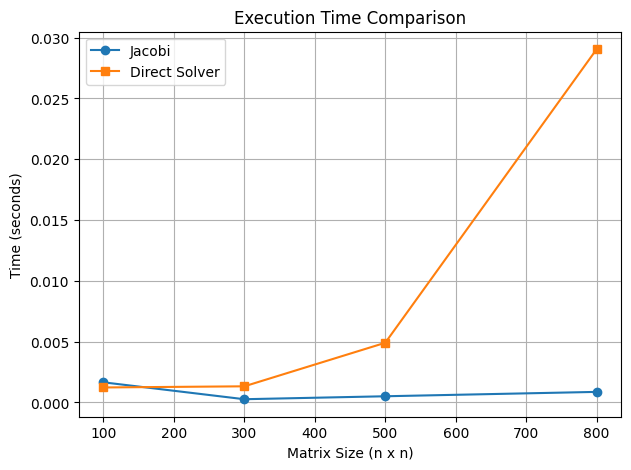

In [9]:
# Execution Time Plot

plt.figure(figsize=(7, 5))

plt.plot(results_df['Matrix Size'], results_df['Jacobi Time'], 'o-', label='Jacobi')
plt.plot(results_df['Matrix Size'], results_df['Direct method Time'], 's-', label='Direct Solver')

plt.xlabel('Matrix Size (n x n)')
plt.ylabel('Time (seconds)')
plt.title('Execution Time Comparison')

plt.legend()
plt.grid(True)
plt.show()

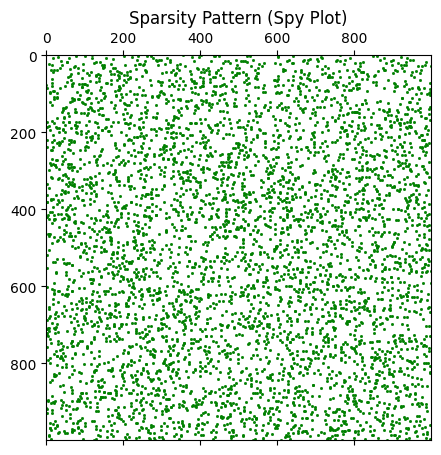

In [10]:
# Sparsity Pattern Visualization

plt.figure(figsize=(7, 5))
plt.spy(sample_matrix, markersize=1, color='green')
plt.title('Sparsity Pattern (Spy Plot)')
plt.show()

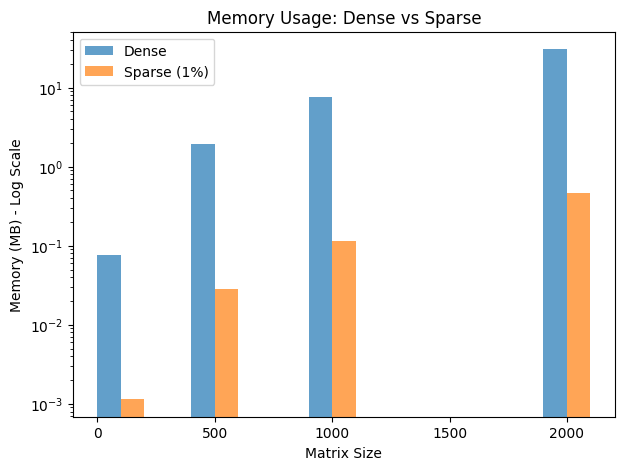

In [11]:
# Memory Usage Demo
plt.figure(figsize=(7, 5))

sizes = [100, 500, 1000, 2000]

dense_mem = [(n**2 * 8) / (1024**2) for n in sizes]
sparse_mem = [(n**2 * 0.01 * 12) / (1024**2) for n in sizes]  # Estimate for CSR

plt.bar(np.array(sizes) - 50, dense_mem, width=100, label='Dense', alpha=0.7)

plt.bar(np.array(sizes) + 50, sparse_mem, width=100, label='Sparse (1%)', alpha=0.7)

plt.yscale('log')

plt.xlabel('Matrix Size')
plt.ylabel('Memory (MB) - Log Scale')
plt.title('Memory Usage: Dense vs Sparse')

plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_21700\1693097665.py:5: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  A_conv = sparse.diags([1, 4, 1], [-1, 0, 1], shape=(100, 100)).tocsr()


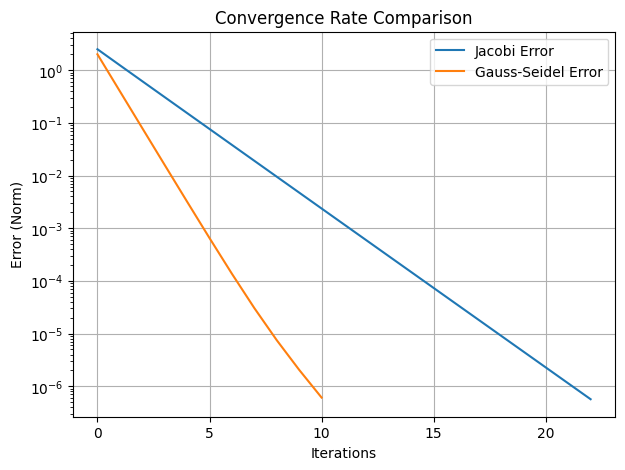

In [12]:
# Convergence Plot

plt.figure(figsize=(7, 5))

A_conv = sparse.diags([1, 4, 1], [-1, 0, 1], shape=(100, 100)).tocsr()

b_conv = np.ones(100)

_, _, _, errs_j = jacobi_solver(A_conv, b_conv, np.zeros(100))
_, _, _, errs_gs = gauss_seidel_solver(A_conv, b_conv, np.zeros(100))

plt.semilogy(errs_j, label='Jacobi Error')
plt.semilogy(errs_gs, label='Gauss-Seidel Error')

plt.xlabel('Iterations')
plt.ylabel('Error (Norm)')
plt.title('Convergence Rate Comparison')

plt.legend()
plt.grid(True)
plt.show()